# Plotting pole figures

This example shows how to plot pole figures with the `neml2.texture` routines. It
loads a crystal plasticity model, uses it to generate reorientation data under
rolling, and then plots three kinds of texture figure: a discrete $\{111\}$ pole
figure, a discrete inverse pole figure, and a continuous $\{111\}$ pole figure
from a reconstructed orientation distribution function (ODF). Along the way it
shows how to reconstruct a continuous ODF from discrete orientations, including
cross-validated selection of the kernel half-width.

The model is the approximated single-crystal formulation in
[`crystal_approximated.i`](crystal_approximated.i) (the same input used by
the [formulations example](formulations)); it is integrated with
[pyzag](https://github.com/Argonne-National-Laboratory/pyzag). See the
[pyzag tutorial](#tutorials-optimization-pyzag) for
more on the pyzag driver.

```{note}
This is a heavier example (500 crystals, 2500 time steps) and is committed
pre-executed; it runs on the GPU when one is available.
```

## Setup

This example simulates rolling in an FCC material: `rate` is the strain rate,
`total_rolling_strain` the reduction strain, `ntime` the number of time steps,
`ncrystal` the number of random initial orientations, and `nchunk` the pyzag
time-integration chunk size.

In [1]:
import matplotlib.pyplot as plt
import torch

import neml2
from neml2.types import MRP, SR2, WR2, Scalar
from neml2.pyzag import NEML2PyzagFactory
import neml2.texture as texture
from pyzag import nonlinear, chunktime

torch.manual_seed(0)
torch.set_default_dtype(torch.double)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

nchunk = 20
ncrystal = 500

rate = 0.0001
total_rolling_strain = 0.5
ntime = 2500
end_time = total_rolling_strain / rate

Using device: cuda:0


The rolling history is the same isochoric stretch used in the formulations
example: extension along $y$, contraction along $z$, no spin. The 500 initial
orientations are sampled uniformly on $SO(3)$ with `MRP.rand`.

In [2]:
deformation_rate = torch.zeros((ntime, ncrystal, 6), device=device)
deformation_rate[:, :, 1] = rate
deformation_rate[:, :, 2] = -rate
deformation_rate = SR2(deformation_rate)
vorticity = WR2(torch.zeros((ntime, ncrystal, 3), device=device))
times = torch.linspace(0, end_time, ntime, device=device).unsqueeze(-1).expand(ntime, ncrystal)

initial_orientations = MRP.rand(ncrystal, device=device)

## Integrate the rolling deformation

The pyzag driver below uses the `NEML2PyzagFactory` to pack the typed force
tensors into the model's flat force layout (`assemble_forces`) and the initial
conditions into the flat state vector (`assemble_state`), integrates the history
with the chunked adjoint solver, and slices the final orientation back out.

In [3]:
def integrate(pmodel, forces, seeds):
    flat_forces = pmodel.assemble_forces(forces)
    state0 = pmodel.assemble_state(seeds)

    solver = nonlinear.RecursiveNonlinearEquationSolver(
        pmodel,
        step_generator=nonlinear.StepGenerator(nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=1.0e-6, atol=1.0e-8),
    )
    return nonlinear.solve_adjoint(solver, state0, len(flat_forces), flat_forces)


def extract(pmodel, history, name):
    offset = 0
    for var in pmodel.slayout.vars():
        size = pmodel.slayout.var_size(var)
        if var == name:
            return history[..., offset : offset + size]
        offset += size
    raise KeyError(name)

In [4]:
nmodel = neml2.load_nonlinear_system("crystal_approximated.i", "eq_sys")
nmodel.model.to(device=device)
pmodel = NEML2PyzagFactory(nmodel, compile=False)

with torch.no_grad():
    history = integrate(
        pmodel,
        {"deformation_rate": deformation_rate.data, "vorticity": vorticity.data, "t": times},
        {
            "elastic_strain": torch.zeros(ncrystal, 6, device=device),
            "slip_hardening": torch.zeros(ncrystal, device=device),
            "orientation": initial_orientations.data,
        },
    )

orientations = MRP(extract(pmodel, history, "orientation")[-1])
print("final orientations:", tuple(orientations.data.shape))

final orientations: (500, 3)


## Discrete pole figure

Plot a discrete $\{111\}$ pole figure of the final orientations under cubic
crystal symmetry (`"432"`). Each crystal contributes its symmetry-equivalent
$\{111\}$ poles projected onto the unit disk.

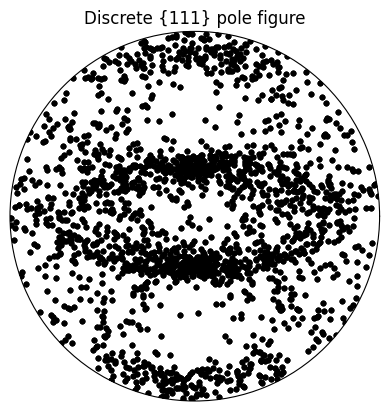

In [5]:
texture.pretty_plot_pole_figure_points(
    orientations, torch.tensor([1.0, 1.0, 1.0], device=device), crystal_symmetry="432"
)
plt.title("Discrete {111} pole figure")
plt.show()

## Discrete inverse pole figure

An inverse pole figure shows which crystal directions align with a chosen sample
direction — here the transverse direction $[0, 1, 0]$.

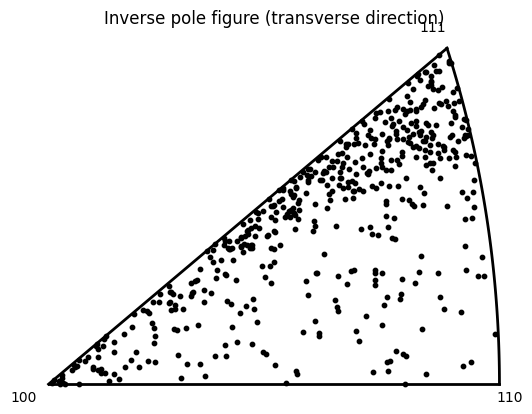

In [6]:
texture.pretty_plot_inverse_pole_figure(
    orientations, torch.tensor([0.0, 1.0, 0.0], device=device), crystal_symmetry="432"
)
plt.title("Inverse pole figure (transverse direction)")
plt.show()

## ODF reconstruction

Reconstruct a continuous ODF from the discrete orientations with a kernel density
estimate. The de la Vallee Poussin kernel half-width is selected by
cross-validation; we print the optimized value.

In [7]:
odf = texture.KDEODF(
    orientations, texture.DeLaValleePoussinKernel(torch.tensor(0.1, device=device))
)
odf.optimize_kernel()
print(f"optimized kernel half-width: {float(odf.kernel.h.detach()):.4f}")

optimized kernel half-width: 0.1837


## Continuous pole figure

Use the reconstructed ODF to plot a smooth, continuous $\{111\}$ pole figure. The
contour values are in multiples of a random distribution (MRD).

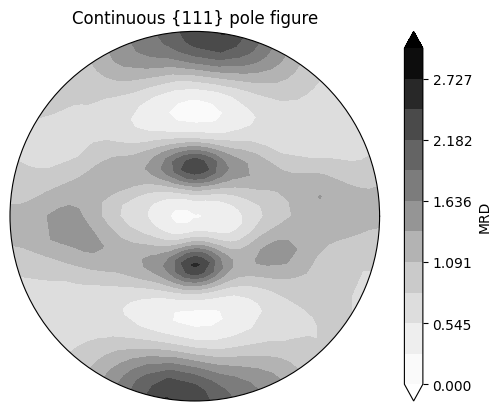

In [8]:
texture.pretty_plot_pole_figure_odf(
    odf,
    torch.tensor([1.0, 1.0, 1.0], device=device),
    crystal_symmetry="432",
    limits=(0.0, 3.0),
    ncontour=12,
)
plt.title("Continuous {111} pole figure")
plt.show()